In [61]:
import numpy as np
import matplotlib.pyplot as plt
import os
from aeon.visualisation import plot_critical_difference
import pandas as pd

SAVE_FIGURES = False
INCLUDE_ABL = False
INCLUDE_PREFIX = False
INCLUDE_CAUSAL = False
assert not (INCLUDE_ABL and INCLUDE_PREFIX ), "Cannot include both ABL and PREFIX in the same plot."
assert not (INCLUDE_PREFIX and INCLUDE_CAUSAL ), "Cannot include both PREFIX and CAUSAL in the same plot."
assert not (INCLUDE_ABL and INCLUDE_CAUSAL ), "Cannot include both ABL and CAUSAL in the same plot."

def load_npz(path):
    data = np.load(path)
    return {k: data[k] for k in data.files}

In [62]:
FIGSIZE = (8, 5)
FONTSIZE = 14
FONTSIZE_TITLE = 17

In [63]:
# models are evaluated at different epochs, so we specify the epoch to load here
LOAD_EPOCH=18

In [64]:
dic_model_colors = {
    "Causal RevIN":          "#FF7F00",  # vivid orange
    "Causal RevIN + asinh":  "#573030FF",  # semi-transparent brown
    "RevIN":                 "#00CC66",  # vivid green
    "RevIN + asinh":         "#0055FF",  # electric deep blue
    "Prefix@4 RevIN":              "#FF3300",  # bright red-orange
    "Prefix@4 RevIN + asinh":      "#CC0099",  # strong magenta

    "No norm":                "#999999",  # medium gray
    "Optimal":                "#000000",  # black
    "Optimal + asinh":        "#573030FF",  # semi-transparent brown

    "Prefix@8 RevIN": "#CC79A7",          # muted magenta
    "Prefix@8 RevIN + asinh": "#56B4E9", # soft cyan-blue
    "Prefix@1 RevIN": "#7B3294",         # deep purple
    "Prefix@1 RevIN + asinh": "#1B9E77", # teal-green  

    "CausalPatchRevIN": "#E69F00",  # orange
    "CausalPatchRevIN + asinh": "#D55E00",  # red-orange
}

dic_model_symbols = {
    "Causal RevIN":          "o",   # circle
    "Causal RevIN + asinh":  "x",   # cross
    "RevIN":                 "s",   # square
    "RevIN + asinh":         "d",   # diamond
    "Prefix@4 RevIN":              "^",   # triangle up
    "Prefix@4 RevIN + asinh":      "v",   # triangle down
    
    "No norm":                "P",   # plus (filled)
    "Optimal":                "*",   # star
    "Optimal + asinh":        "D",   # diamond

    "Prefix@8 RevIN":              "^",   # triangle up
    "Prefix@8 RevIN + asinh":      "v",   # triangle down
    "Prefix@1 RevIN":              "^",   # triangle up
    "Prefix@1 RevIN + asinh":      "v",   # triangle down

    "CausalPatchRevIN":              "o",   # circle
    "CausalPatchRevIN + asinh":      "x",   # cross
}

# Ranks per context length

In [65]:
CTX_LEN=512
assert CTX_LEN in [64, 128, 256, 512, 1024]

In [66]:
metrics_causal_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/causal/{CTX_LEN}.npz")
metrics_causal_asinh_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/causalsinh/{CTX_LEN}.npz")
metrics_asinh_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/vanillasinh/{CTX_LEN}.npz")
metrics_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/vanilla/{CTX_LEN}.npz")
metrics_Prefix_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/prefix4/{CTX_LEN}.npz")
metrics_Prefix_asinh_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/prefix4sinh/{CTX_LEN}.npz")

metrics_no_norm_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/none/{CTX_LEN}.npz")
metrics_optimal_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/optimal/{CTX_LEN}.npz")
metrics_optimalsinh_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/optimalsinh/{CTX_LEN}.npz")

metrics_Prefix8_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/prefix8/{CTX_LEN}.npz")
metrics_Prefix8_asinh_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/prefix8sinh/{CTX_LEN}.npz")
metrics_Prefix1_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/prefix1/{CTX_LEN}.npz")
metrics_Prefix1_asinh_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/prefix1sinh/{CTX_LEN}.npz")

metrics_CausalPatch_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/causalpatch/{CTX_LEN}.npz")
metrics_CausalPatch_asinh_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/causalsinhpatch/{CTX_LEN}.npz")

# Critical Rank Diagram

## Aggregated by forecast horizon

In [67]:
import pandas as pd
from collections import defaultdict

if INCLUDE_ABL:
    MODEL_METRICS = {
        'Causal RevIN':           {'GIFT-Eval': metrics_causal_gift_eval},
        'Causal RevIN + asinh':   {'GIFT-Eval': metrics_causal_asinh_gift_eval},
        'RevIN + asinh':          {'GIFT-Eval': metrics_asinh_gift_eval},
        'RevIN':                  {'GIFT-Eval': metrics_gift_eval},
        'Prefix@4 RevIN':           {'GIFT-Eval': metrics_Prefix_gift_eval},
        'Prefix@4 RevIN + asinh':   {'GIFT-Eval': metrics_Prefix_asinh_gift_eval},
    }
    MODEL_METRICS['No norm'] = {'GIFT-Eval': metrics_no_norm_gift_eval}
    MODEL_METRICS['Optimal'] = {'GIFT-Eval': metrics_optimal_gift_eval}
    MODEL_METRICS['Optimal + asinh'] = {'GIFT-Eval': metrics_optimalsinh_gift_eval}

elif INCLUDE_PREFIX:
    MODEL_METRICS = {
        #'Prefix@4 RevIN':           {'GIFT-Eval': metrics_Prefix_gift_eval},
        'Prefix@4 RevIN + asinh':   {'GIFT-Eval': metrics_Prefix_asinh_gift_eval},
    }
    #MODEL_METRICS['Prefix@8 RevIN'] = {'GIFT-Eval': metrics_Prefix8_gift_eval}
    MODEL_METRICS['Prefix@8 RevIN + asinh'] = {'GIFT-Eval': metrics_Prefix8_asinh_gift_eval}
    #MODEL_METRICS['Prefix@1 RevIN'] = {'GIFT-Eval': metrics_Prefix1_gift_eval}
    MODEL_METRICS['Prefix@1 RevIN + asinh'] = {'GIFT-Eval': metrics_Prefix1_asinh_gift_eval}

elif INCLUDE_CAUSAL:
    MODEL_METRICS = {
        'Causal RevIN':           {'GIFT-Eval': metrics_causal_gift_eval},
        'Causal RevIN + asinh':   {'GIFT-Eval': metrics_causal_asinh_gift_eval},
    }
    MODEL_METRICS['CausalPatchRevIN'] = {'GIFT-Eval': metrics_CausalPatch_gift_eval}
    MODEL_METRICS['CausalPatchRevIN + asinh'] = {'GIFT-Eval': metrics_CausalPatch_asinh_gift_eval}

else:
    MODEL_METRICS = {
        'Causal RevIN':           {'GIFT-Eval': metrics_causal_gift_eval},
        'Causal RevIN + asinh':   {'GIFT-Eval': metrics_causal_asinh_gift_eval},
        'RevIN + asinh':          {'GIFT-Eval': metrics_asinh_gift_eval},
        'RevIN':                  {'GIFT-Eval': metrics_gift_eval},
        'Prefix@4 RevIN':           {'GIFT-Eval': metrics_Prefix_gift_eval},
        'Prefix@4 RevIN + asinh':   {'GIFT-Eval': metrics_Prefix_asinh_gift_eval},
    }

METRIC_KEYS = {"mae", "rmse", "mase", "sql"}

def flatten_metrics(model_metrics: dict) -> dict[str, dict]:
    result = defaultdict(lambda: defaultdict(dict))

    for model_name, datasets in model_metrics.items():
        for dataset_name, metrics in datasets.items():
            for key, values in metrics.items():
                metric, size = key.split("_", 1)
                metric = metric.lower()
                if metric not in METRIC_KEYS:
                    continue
                for i, val in enumerate(values):
                    col = f"{dataset_name}_{size}_{i}"
                    result[metric][model_name][col] = val

    return {k: dict(v) for k, v in result.items()}


flat = flatten_metrics(MODEL_METRICS)
new_df_mae  = flat["mae"]
new_df_mse  = flat["rmse"]
new_df_mase = flat["mase"]
new_df_sql  = flat["sql"]

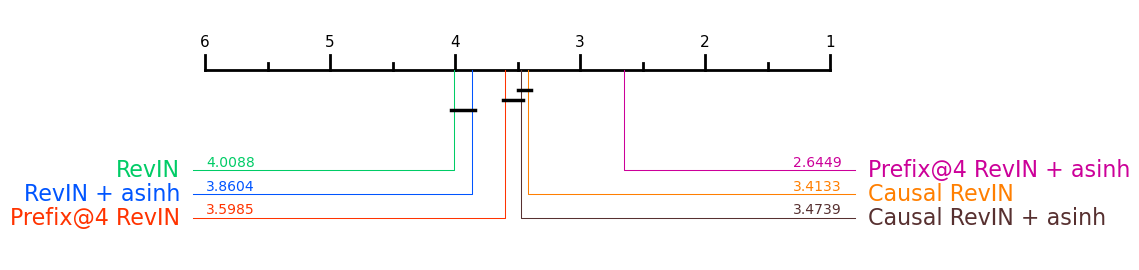

In [68]:
# Create Critical Difference plot for MAE
df_mae = pd.DataFrame(new_df_mae)
methods = df_mae.columns
plot = plot_critical_difference(df_mae.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True, highlight=dic_model_colors)

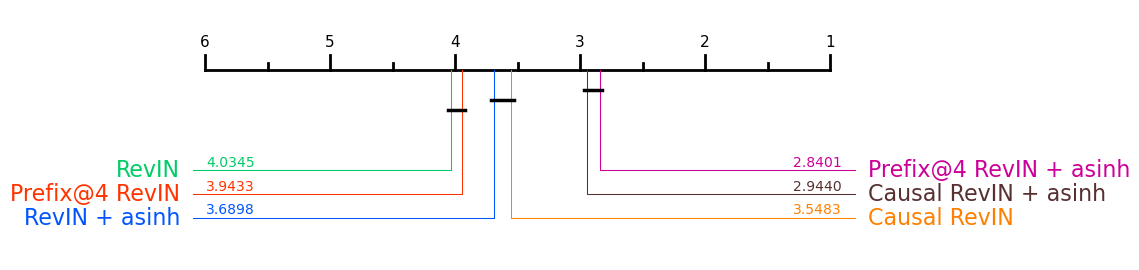

In [69]:
# Create Critical Difference plot for RMSE
df_mse = pd.DataFrame(new_df_mse)
methods = df_mse.columns
plot = plot_critical_difference(df_mse.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True, highlight=dic_model_colors)

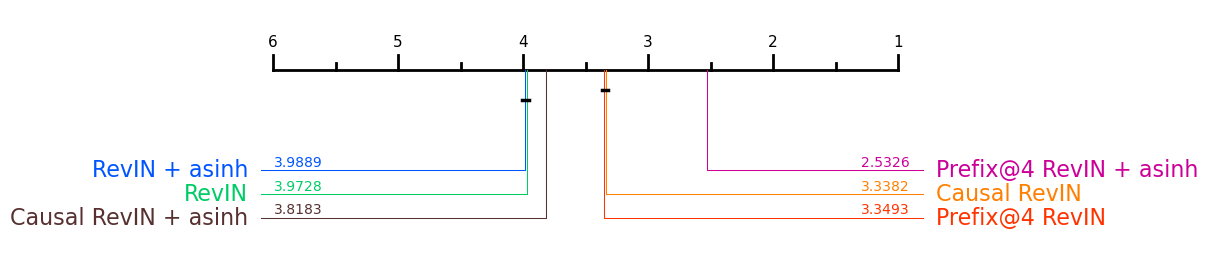

In [70]:
# Create Critical Difference plot for MASE
df_mase = pd.DataFrame(new_df_mase)
methods = df_mase.columns
plot = plot_critical_difference(df_mase.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True, highlight=dic_model_colors)

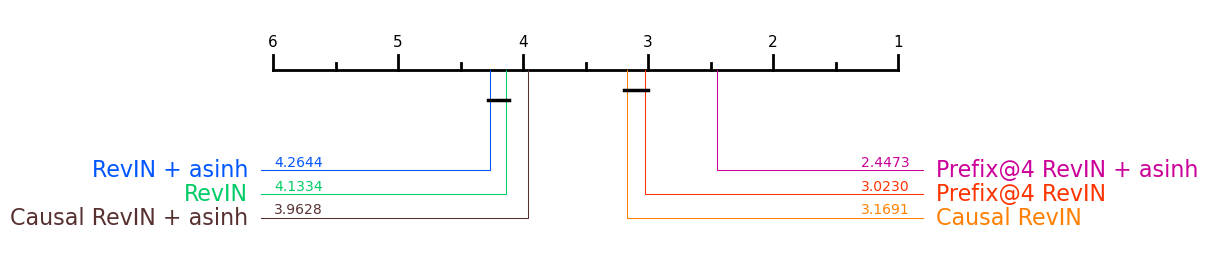

In [71]:
# Create Critical Difference plot for SQL
df_sql = pd.DataFrame(new_df_sql)
methods = df_sql.columns
plot = plot_critical_difference(df_sql.values, methods, alpha=0.05, width=8, test='nemenyi', lower_better=True, highlight=dic_model_colors)

In [72]:
SIZE_KEYS = sorted(set(int(e.split("_")[1]) for e in MODEL_METRICS[next(iter(MODEL_METRICS))]["GIFT-Eval"].keys()))

ranks_per_size = {m: {s: {} for s in SIZE_KEYS} for m in METRIC_KEYS}
for metric in METRIC_KEYS:
    subdf = {size:{} for size in SIZE_KEYS}
    for model_name in MODEL_METRICS.keys():
        for key, value in MODEL_METRICS[model_name]["GIFT-Eval"].items():
            m, size = key.split("_", 1)
            m = m.lower()
            if m != metric:
                continue
            size = int(size)
            subdf[size][model_name] = value
    for size, data in subdf.items():
        df = pd.DataFrame(data)
        ranks = df.rank(axis=1, method='average', ascending=True)
        ranks_per_size[metric][size] = ranks.mean().to_dict()

## Evolution of ranks with forecast horizon

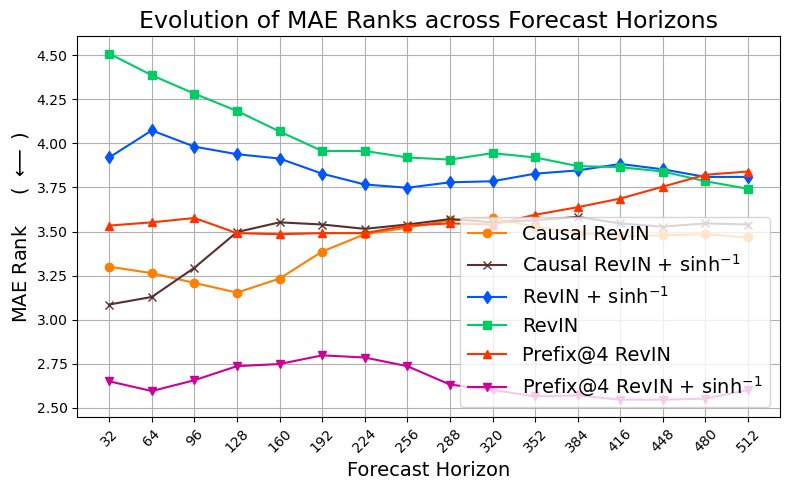

In [73]:
# MAE PLOT

plt.figure(figsize=FIGSIZE)
for model_name in MODEL_METRICS.keys():
    curr_model_ranks = [ranks_per_size["mae"][size][model_name] for size in SIZE_KEYS]
    plt.plot(curr_model_ranks, marker=dic_model_symbols[model_name], label=model_name.replace('asinh', "$\sinh^{-1}$"), color=dic_model_colors[model_name])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(SIZE_KEYS)), SIZE_KEYS, rotation=45)
plt.title("Evolution of MAE Ranks across Forecast Horizons", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MAE Rank     ( $\longleftarrow$ )", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
if not INCLUDE_ABL and not INCLUDE_PREFIX and SAVE_FIGURES:
    plt.savefig(f'figures/plots/mae_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

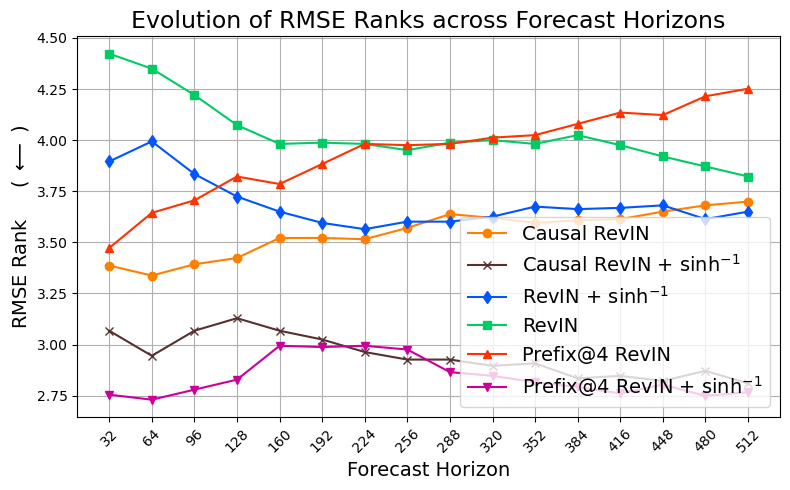

In [74]:
# RMSE PLOT

plt.figure(figsize=FIGSIZE)
for model_name in MODEL_METRICS.keys():
    curr_model_ranks = [ranks_per_size["rmse"][size][model_name] for size in SIZE_KEYS]
    plt.plot(curr_model_ranks, marker=dic_model_symbols[model_name], label=model_name.replace('asinh', "$\sinh^{-1}$"), color=dic_model_colors[model_name])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(SIZE_KEYS)), SIZE_KEYS, rotation=45)
plt.title("Evolution of RMSE Ranks across Forecast Horizons", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("RMSE Rank     ( $\longleftarrow$ )", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
if not INCLUDE_ABL and not INCLUDE_PREFIX and SAVE_FIGURES:
    plt.savefig(f'figures/plots/rmse_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

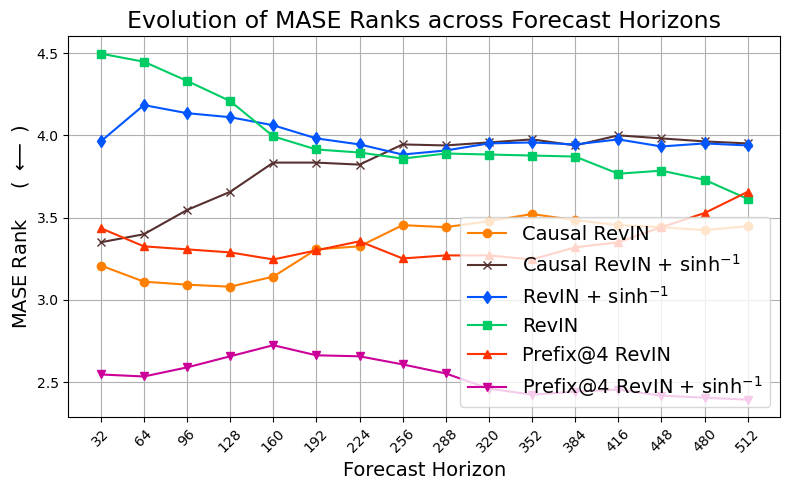

In [75]:
# MASE PLOT

plt.figure(figsize=FIGSIZE)
for model_name in MODEL_METRICS.keys():
    curr_model_ranks = [ranks_per_size["mase"][size][model_name] for size in SIZE_KEYS]
    plt.plot(curr_model_ranks, marker=dic_model_symbols[model_name], label=model_name.replace('asinh', "$\sinh^{-1}$"), color=dic_model_colors[model_name])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(SIZE_KEYS)), SIZE_KEYS, rotation=45)
plt.title("Evolution of MASE Ranks across Forecast Horizons", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("MASE Rank     ( $\longleftarrow$ )", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()
if not INCLUDE_ABL and not INCLUDE_PREFIX and SAVE_FIGURES:
    plt.savefig(f'figures/plots/mase_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

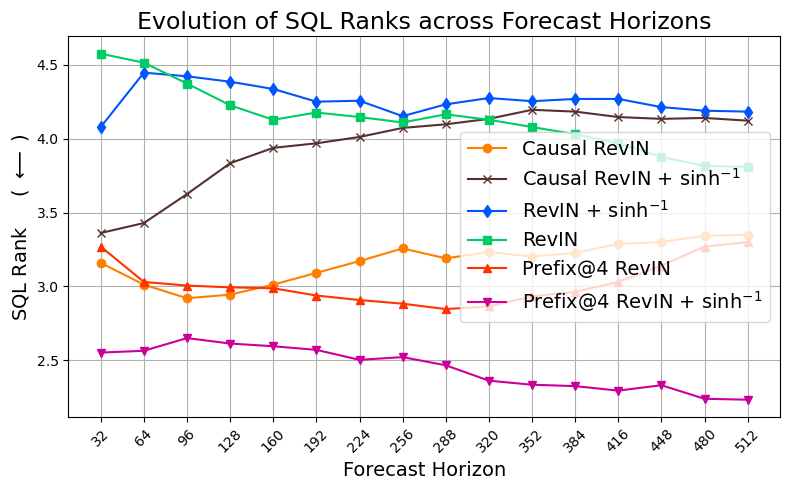

In [76]:
# SQL PLOT

plt.figure(figsize=FIGSIZE)
for model_name in MODEL_METRICS.keys():
    curr_model_ranks = [ranks_per_size["sql"][size][model_name] for size in SIZE_KEYS]
    plt.plot(curr_model_ranks, marker=dic_model_symbols[model_name], label=model_name.replace('asinh', "$\sinh^{-1}$"), color=dic_model_colors[model_name])
plt.legend(fontsize=FONTSIZE)
plt.xticks(range(len(SIZE_KEYS)), SIZE_KEYS, rotation=45)
plt.title("Evolution of SQL Ranks across Forecast Horizons", fontsize=FONTSIZE_TITLE)
plt.xlabel("Forecast Horizon", fontsize=FONTSIZE)
plt.ylabel("SQL Rank     ( $\longleftarrow$ )", fontsize=FONTSIZE)
plt.grid()
plt.tight_layout()

if not INCLUDE_ABL and not INCLUDE_PREFIX and SAVE_FIGURES:
    plt.savefig(f'figures/plots/sql_ranking_horizon_gift_eval_{CTX_LEN}.pdf', format='pdf', dpi=300)
plt.show()

# Barplots per context length

In [77]:
ALL_CTX_LEN = [64, 128, 256, 512, 1024]
ranks_per_ctx_len = {m: {c: {} for c in ALL_CTX_LEN} for m in METRIC_KEYS}

for ctx in ALL_CTX_LEN:
    
    #metrics_causal_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/causal/{ctx}.npz")
    #metrics_causal_asinh_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/causalsinh/{ctx}.npz")
    #metrics_asinh_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/vanillasinh/{ctx}.npz")
    #metrics_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/vanilla/{ctx}.npz")

    metrics_Prefix_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/prefix4/{ctx}.npz")
    metrics_Prefix_asinh_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/prefix4sinh/{ctx}.npz")
    metrics_Prefix1_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/prefix1/{ctx}.npz")
    metrics_Prefix1_asinh_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/prefix1sinh/{ctx}.npz")
    metrics_Prefix8_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/prefix8/{ctx}.npz")
    metrics_Prefix8_asinh_gift_eval = load_npz(f"../results/{LOAD_EPOCH}/prefix8sinh/{ctx}.npz")

    MODEL_METRICS = {
        #'Causal RevIN':           {'GIFT-Eval': metrics_causal_gift_eval},
        #'Causal RevIN + asinh':   {'GIFT-Eval': metrics_causal_asinh_gift_eval},
        #'RevIN + asinh':          {'GIFT-Eval': metrics_asinh_gift_eval},
        #'RevIN':                  {'GIFT-Eval': metrics_gift_eval},
        'Prefix@4 RevIN':           {'GIFT-Eval': metrics_Prefix_gift_eval},
        'Prefix@1 RevIN':           {'GIFT-Eval': metrics_Prefix1_gift_eval},
        'Prefix@8 RevIN':           {'GIFT-Eval': metrics_Prefix8_gift_eval},
        
        'Prefix@4 RevIN + asinh':   {'GIFT-Eval': metrics_Prefix_asinh_gift_eval},
        'Prefix@1 RevIN + asinh':   {'GIFT-Eval': metrics_Prefix1_asinh_gift_eval},
        'Prefix@8 RevIN + asinh':   {'GIFT-Eval': metrics_Prefix8_asinh_gift_eval},
    }

    def flatten_metrics(model_metrics: dict) -> dict[str, dict]:
        result = defaultdict(lambda: defaultdict(dict))

        for model_name, datasets in model_metrics.items():
            for dataset_name, metrics in datasets.items():
                for key, values in metrics.items():
                    metric, size = key.split("_", 1)
                    metric = metric.lower()
                    if metric not in METRIC_KEYS:
                        continue
                    for i, val in enumerate(values):
                        col = f"{dataset_name}_{size}_{i}"
                        result[metric][model_name][col] = val

        return {k: dict(v) for k, v in result.items()}


    flat = flatten_metrics(MODEL_METRICS)
    new_df_mae  = flat["mae"]
    new_df_mse  = flat["rmse"]
    new_df_mase = flat["mase"]
    new_df_sql  = flat["sql"]

    ranks_mae = pd.DataFrame(new_df_mae).rank(axis=1, method='average', ascending=True).mean().to_dict()
    ranks_mse = pd.DataFrame(new_df_mse).rank(axis=1, method='average', ascending=True).mean().to_dict()
    ranks_mase = pd.DataFrame(new_df_mase).rank(axis=1, method='average', ascending=True).mean().to_dict()
    ranks_sql = pd.DataFrame(new_df_sql).rank(axis=1, method='average', ascending=True).mean().to_dict()

    for model_name in MODEL_METRICS.keys():
        ranks_per_ctx_len["mae"][ctx][model_name] = ranks_mae[model_name]
        ranks_per_ctx_len["rmse"][ctx][model_name] = ranks_mse[model_name]
        ranks_per_ctx_len["mase"][ctx][model_name] = ranks_mase[model_name]
        ranks_per_ctx_len["sql"][ctx][model_name] = ranks_sql[model_name]

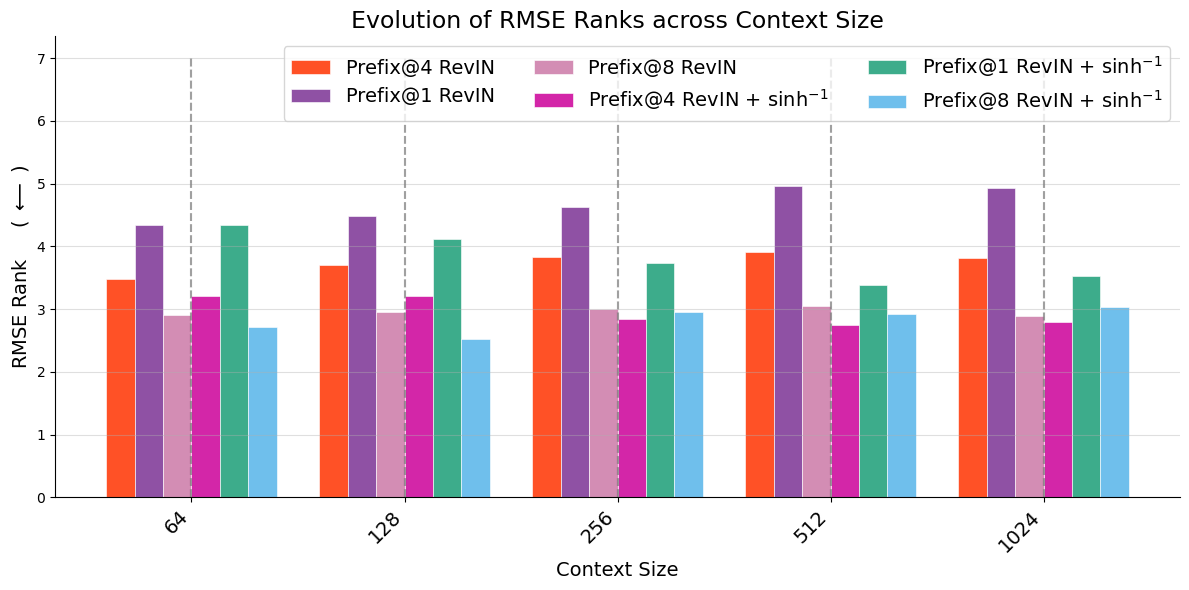

In [78]:
x = np.arange(len(ALL_CTX_LEN))
width = 0.8 / len(MODEL_METRICS)

FIGSIZE = (12, 6)
fig, ax = plt.subplots(figsize=FIGSIZE)

for ctx_i, ctx in enumerate(ALL_CTX_LEN):

    for bar_i, model_name in enumerate(MODEL_METRICS.keys()):
        rank = ranks_per_ctx_len["rmse"][ctx][model_name]
        offset = (bar_i - len(MODEL_METRICS) / 2 + 0.5) * width
        ax.bar(ctx_i + offset, rank, width, label=model_name.replace('asinh', "$\sinh^{-1}$") if ctx_i == 0 else "",
               color=dic_model_colors[model_name], alpha=0.85,
               edgecolor="white", linewidth=0.5)
        ax.vlines(ctx_i, 0, len(MODEL_METRICS)+1, color="gray", alpha=0.2, linestyle="--")

ax.set_xticks(x)
ax.set_xticklabels(ALL_CTX_LEN, rotation=45, ha="right", fontsize=FONTSIZE)
ax.set_xlabel("Context Size", fontsize=FONTSIZE)
ax.set_ylabel("RMSE Rank     ( $\longleftarrow$ )", fontsize=FONTSIZE)
ax.set_title("Evolution of RMSE Ranks across Context Size", fontsize=FONTSIZE_TITLE)
ax.legend(fontsize=FONTSIZE, ncols=len(MODEL_METRICS)//2)
ax.grid(axis="y", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

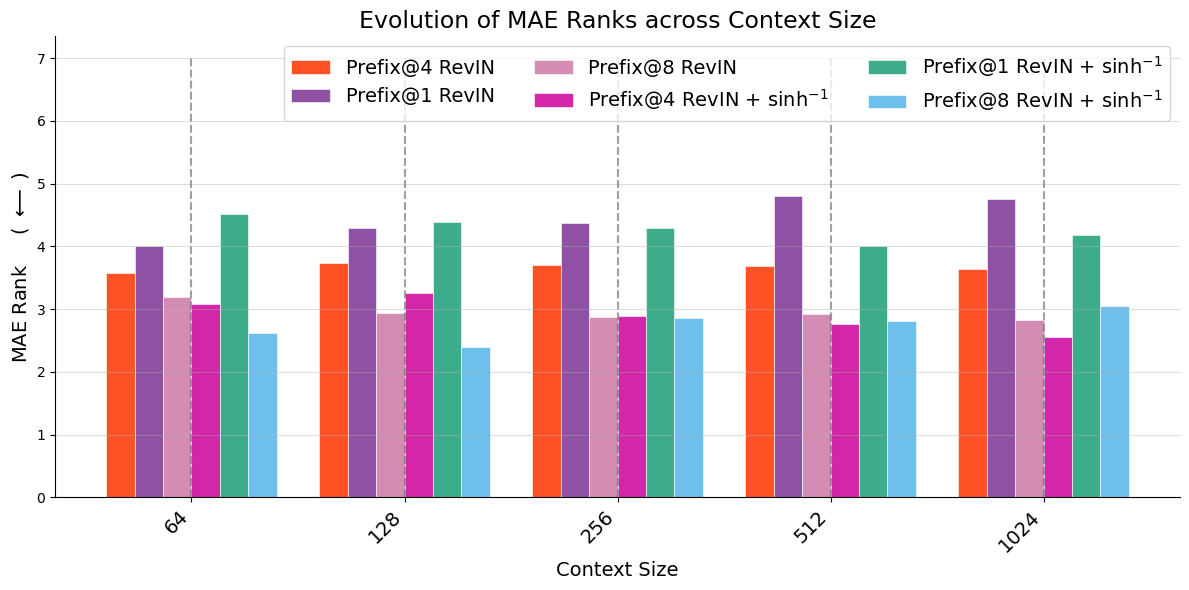

In [79]:
x = np.arange(len(ALL_CTX_LEN))
width = 0.8 / len(MODEL_METRICS)

FIGSIZE = (12, 6)
fig, ax = plt.subplots(figsize=FIGSIZE)

for ctx_i, ctx in enumerate(ALL_CTX_LEN):

    for bar_i, model_name in enumerate(MODEL_METRICS.keys()):
        rank = ranks_per_ctx_len["mae"][ctx][model_name]
        offset = (bar_i - len(MODEL_METRICS) / 2 + 0.5) * width
        ax.bar(ctx_i + offset, rank, width, label=model_name.replace('asinh', "$\sinh^{-1}$") if ctx_i == 0 else "",
               color=dic_model_colors[model_name], alpha=0.85,
               edgecolor="white", linewidth=0.5)
        ax.vlines(ctx_i, 0, len(MODEL_METRICS)+1, color="gray", alpha=0.2, linestyle="--")

ax.set_xticks(x)
ax.set_xticklabels(ALL_CTX_LEN, rotation=45, ha="right", fontsize=FONTSIZE)
ax.set_xlabel("Context Size", fontsize=FONTSIZE)
ax.set_ylabel("MAE Rank     ( $\longleftarrow$ )", fontsize=FONTSIZE)
ax.set_title("Evolution of MAE Ranks across Context Size", fontsize=FONTSIZE_TITLE)
ax.legend(fontsize=FONTSIZE, ncols=len(MODEL_METRICS)//2)
ax.grid(axis="y", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

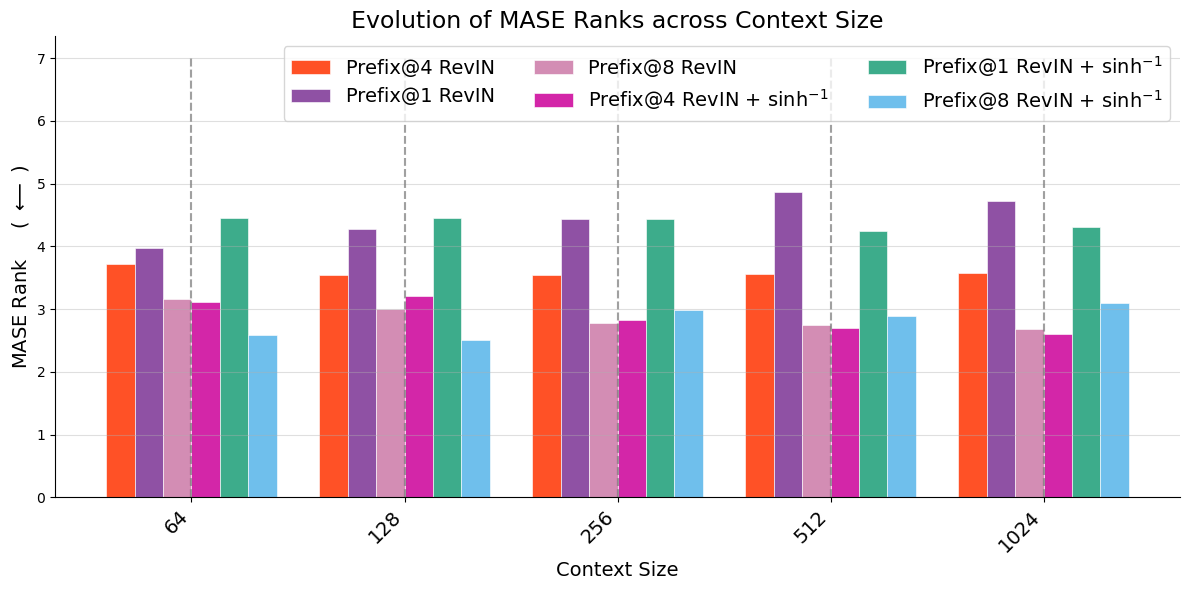

In [80]:
x = np.arange(len(ALL_CTX_LEN))
width = 0.8 / len(MODEL_METRICS)

FIGSIZE = (12, 6)
fig, ax = plt.subplots(figsize=FIGSIZE)

for ctx_i, ctx in enumerate(ALL_CTX_LEN):

    for bar_i, model_name in enumerate(MODEL_METRICS.keys()):
        rank = ranks_per_ctx_len["mase"][ctx][model_name]
        offset = (bar_i - len(MODEL_METRICS) / 2 + 0.5) * width
        ax.bar(ctx_i + offset, rank, width, label=model_name.replace('asinh', "$\sinh^{-1}$") if ctx_i == 0 else "",
               color=dic_model_colors[model_name], alpha=0.85,
               edgecolor="white", linewidth=0.5)
        ax.vlines(ctx_i, 0, len(MODEL_METRICS)+1, color="gray", alpha=0.2, linestyle="--")

ax.set_xticks(x)
ax.set_xticklabels(ALL_CTX_LEN, rotation=45, ha="right", fontsize=FONTSIZE)
ax.set_xlabel("Context Size", fontsize=FONTSIZE)
ax.set_ylabel("MASE Rank     ( $\longleftarrow$ )", fontsize=FONTSIZE)
ax.set_title("Evolution of MASE Ranks across Context Size", fontsize=FONTSIZE_TITLE)
ax.legend(fontsize=FONTSIZE, ncols=len(MODEL_METRICS)//2)
ax.grid(axis="y", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

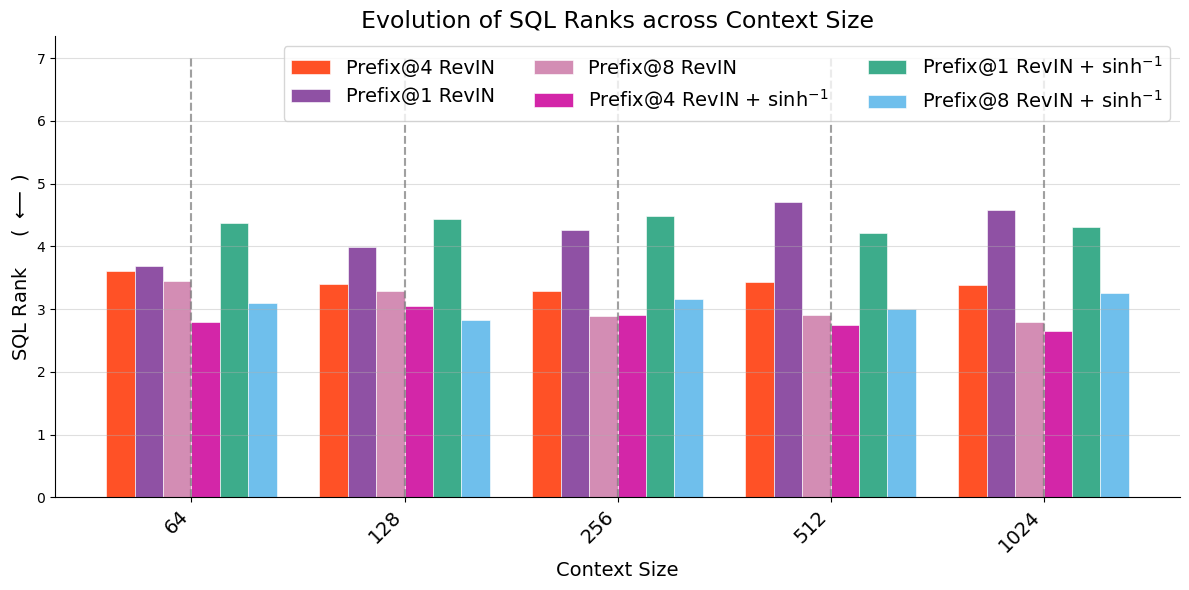

In [81]:
x = np.arange(len(ALL_CTX_LEN))
width = 0.8 / len(MODEL_METRICS)

FIGSIZE = (12, 6)
fig, ax = plt.subplots(figsize=FIGSIZE)

for ctx_i, ctx in enumerate(ALL_CTX_LEN):

    for bar_i, model_name in enumerate(MODEL_METRICS.keys()):
        rank = ranks_per_ctx_len["sql"][ctx][model_name]
        offset = (bar_i - len(MODEL_METRICS) / 2 + 0.5) * width
        ax.bar(ctx_i + offset, rank, width, label=model_name.replace('asinh', "$\sinh^{-1}$") if ctx_i == 0 else "",
               color=dic_model_colors[model_name], alpha=0.85,
               edgecolor="white", linewidth=0.5)
        ax.vlines(ctx_i, 0, len(MODEL_METRICS)+1, color="gray", alpha=0.2, linestyle="--")

ax.set_xticks(x)
ax.set_xticklabels(ALL_CTX_LEN, rotation=45, ha="right", fontsize=FONTSIZE)
ax.set_xlabel("Context Size", fontsize=FONTSIZE)
ax.set_ylabel("SQL Rank     ( $\longleftarrow$ )", fontsize=FONTSIZE)
ax.set_title("Evolution of SQL Ranks across Context Size", fontsize=FONTSIZE_TITLE)
ax.legend(fontsize=FONTSIZE, ncols=len(MODEL_METRICS)//2)
ax.grid(axis="y", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()